# 2.1 — Базовые модели (MLP, GRU, TCN)

**Папка 2 «Обучение моделей», подноутбук 1.** Для каждой базовой модели выполняется
**подбор гиперпараметров перебором по сетке (grid search)** с богатой историей (все метрики
по каждой конфигурации). Метрика отбора выбирается явно. Лучшая комбинация сохраняется в
`models/<имя>/hyperparams.json`, после чего финальное обучение **читает этот JSON** и обучает
модель «начисто» с отслеживанием метрик. Рисунки и таблицы — на английском.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import (GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline,
                                    TransformerBaseline, FTTransformer, CatBoostBaseline,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow)

device: cpu | dims static/prefix/seq: 34 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Censored mean absolute error of the predicted ...
5,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
6,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
7,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...
8,ECE,Expected calibration error,–,lower is better,Average absolute gap between predicted confide...
9,Coverage_90,90% interval coverage,–,target ≈ 0.9,Empirical fraction of true PPR values that fal...


## Шаг 1. Grid search, история по всем метрикам и сохранение гиперпараметров

Для каждой модели задана своя метрика отбора `score` (можно менять). Дашборд показывает
все метрики по каждой конфигурации; лучшая по метрике отбора подсвечена.

[MLP-Risk] selection metric = Brier | best = {'hidden_dim': 128}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,128,0.4965,186.7135,368.4124,0.7477,0.9593,101.0,1.0202,216.2726,0.6575,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,64,0.3734,296.4708,656.9977,0.6723,1.0652,101.0,0.9132,360.8514,0.3425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


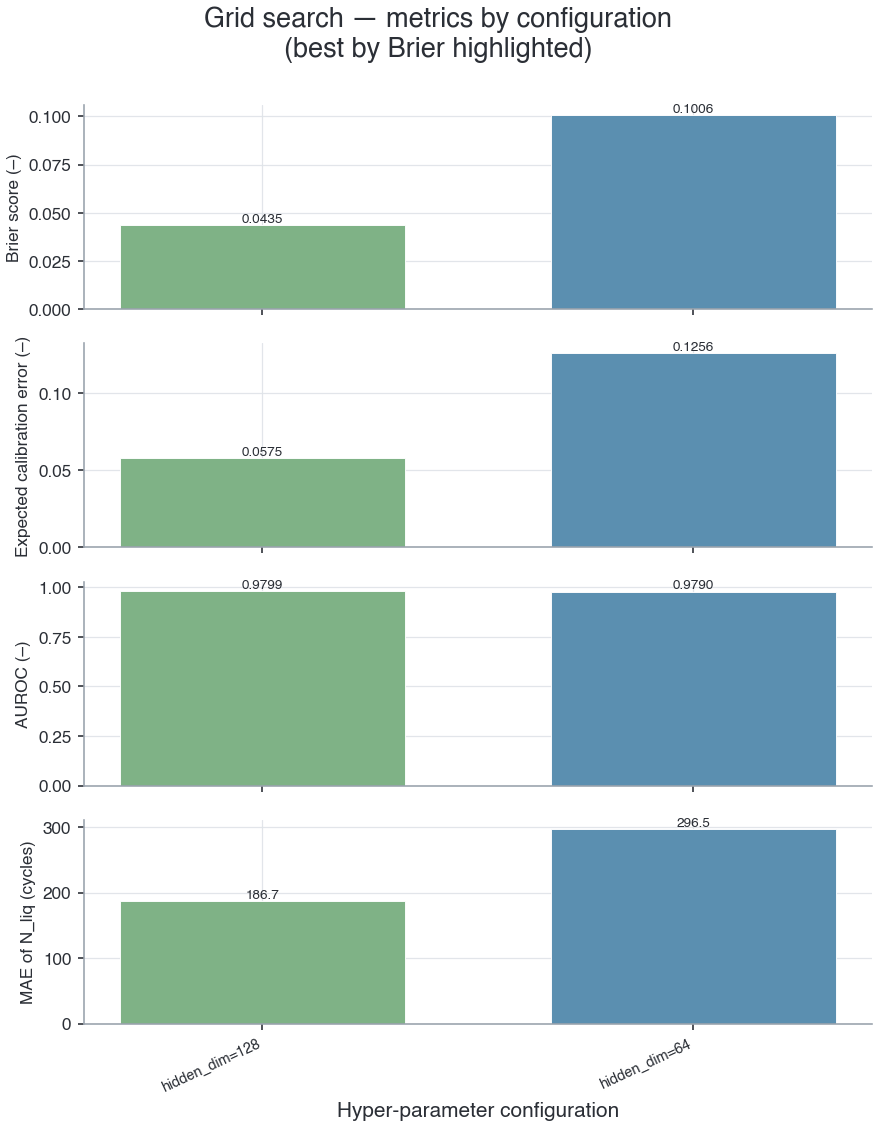

[GRU] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,64,-0.7968,1371.5956,1376.1494,2.0216,2.2256,101.0,2.5239,1311.3231,0.0,...,0.7003,0.9932,0.8344,0.0999,-0.4332,0.0829,NaN,0.0,0.0,0.0
1,96,-0.8647,1483.7794,1557.6664,2.0991,2.4203,101.0,2.7914,1760.9357,0.0,...,0.3361,0.8488,0.4004,0.1117,-0.5863,0.0773,NaN,0.0,0.0,0.0


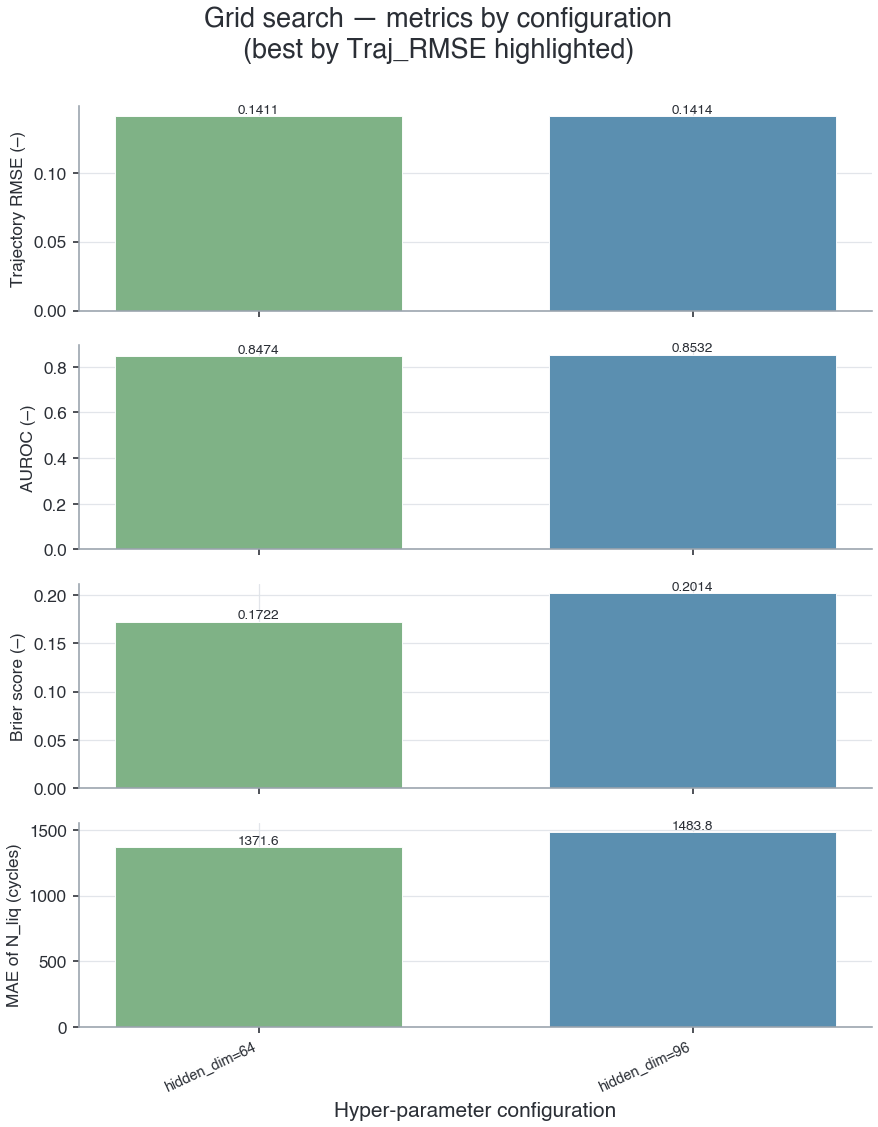

[TCN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-0.4365,1631.9978,1784.9594,2.1764,2.5466,101.0,2.9381,2060.6836,0.0,...,0.4327,0.9734,0.5156,0.0447,-0.8003,0.0712,NaN,0.0,0.0,0.0
1,64,-1.4026,2057.5742,2399.1372,2.3481,2.7928,101.0,3.2394,2819.5718,0.0,...,0.3574,0.9376,0.4259,0.0243,-0.6542,0.0736,NaN,0.0,0.0,0.0


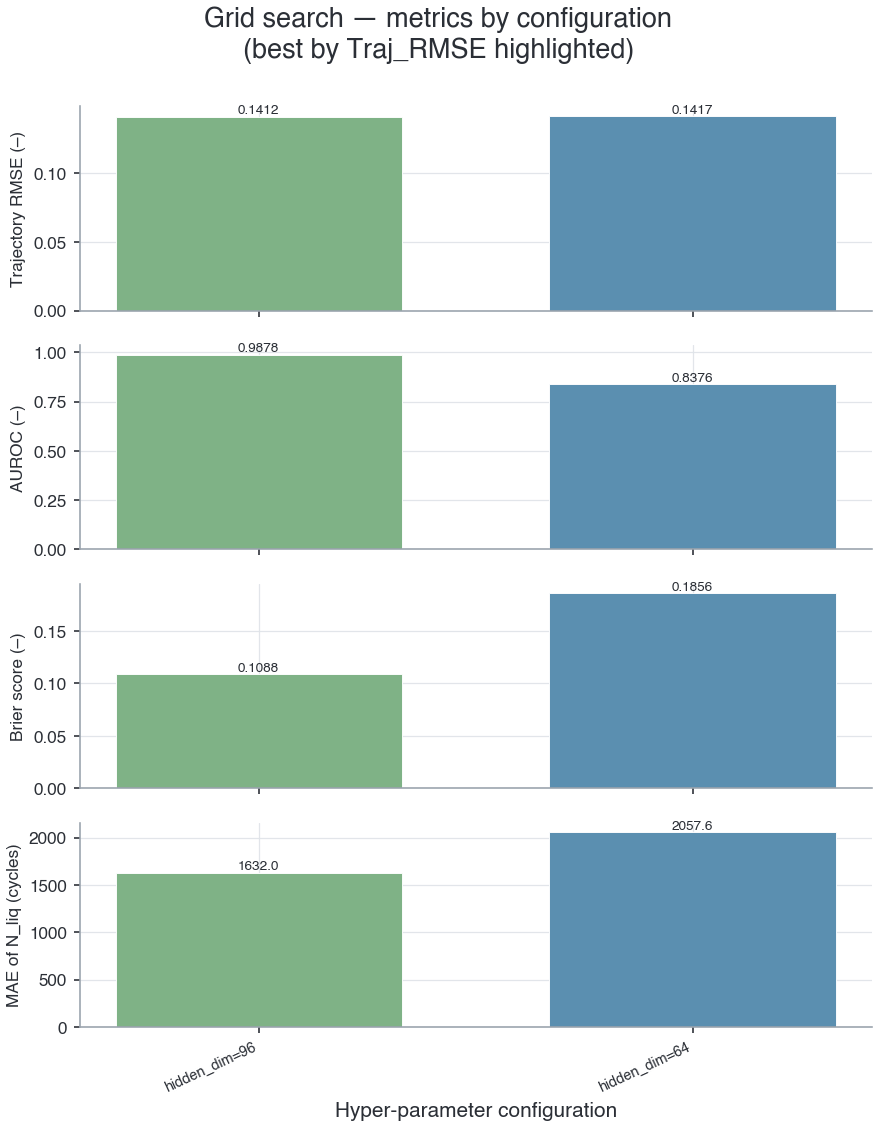

[LSTM] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,64,-1.1271,1912.9347,2047.3989,2.3002,2.6545,101.0,3.0673,2353.7300,0.0,...,0.5485,0.9585,0.6535,0.0330,-0.4779,0.0931,NaN,0.0,0.0,0.0
1,96,-0.6687,1721.6581,1795.6543,2.2186,2.5389,101.0,2.9281,2030.0284,0.0,...,0.5422,0.9077,0.6461,0.0263,-0.3264,0.0983,NaN,0.0,0.0,0.0


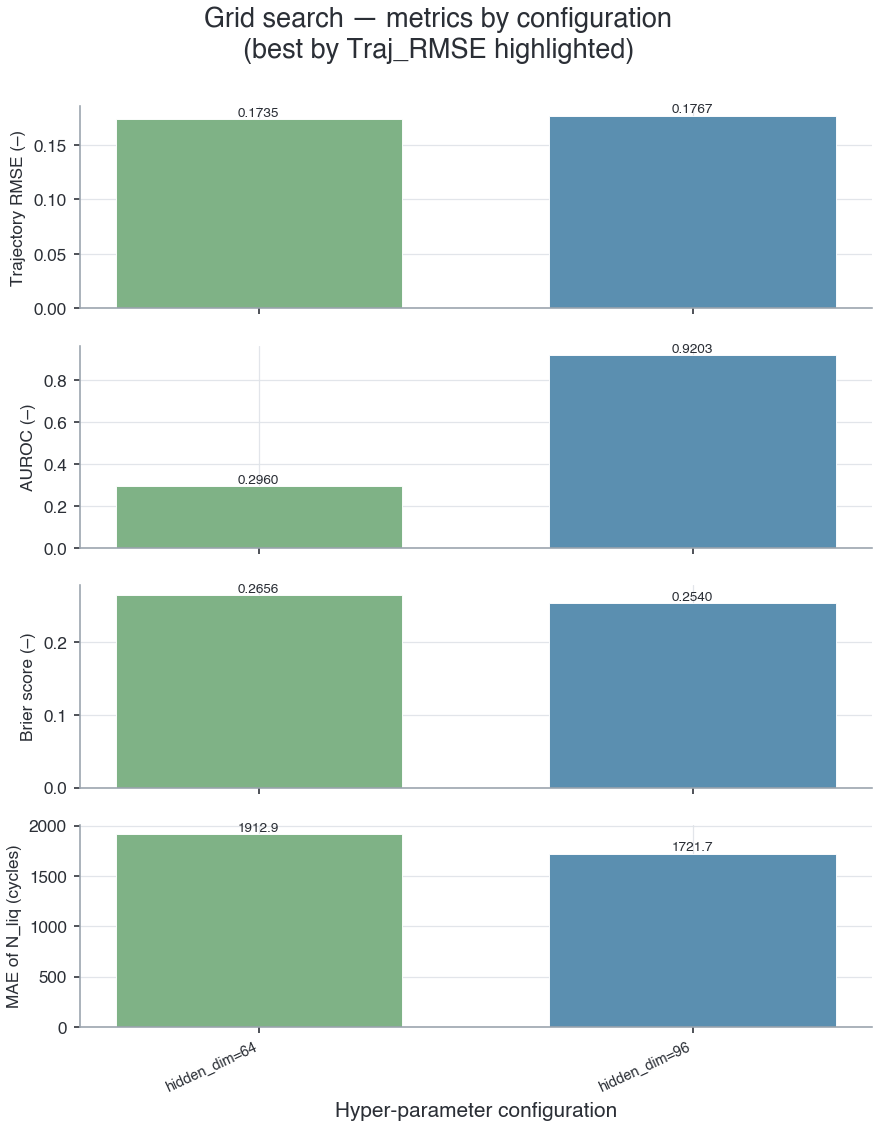

[Transformer] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-2.0307,268.9327,516.1829,0.7718,1.0683,101.0,1.0296,263.2326,0.6986,...,0.2278,0.9417,0.2714,0.0308,-1.3383,0.0409,NaN,0.0,0.0,0.0
1,64,-1.5555,392.3364,594.9674,0.7174,1.0221,101.0,0.8952,288.0750,0.4110,...,0.2047,0.8703,0.2439,0.0870,-0.9132,0.0516,NaN,0.0,0.0,0.0


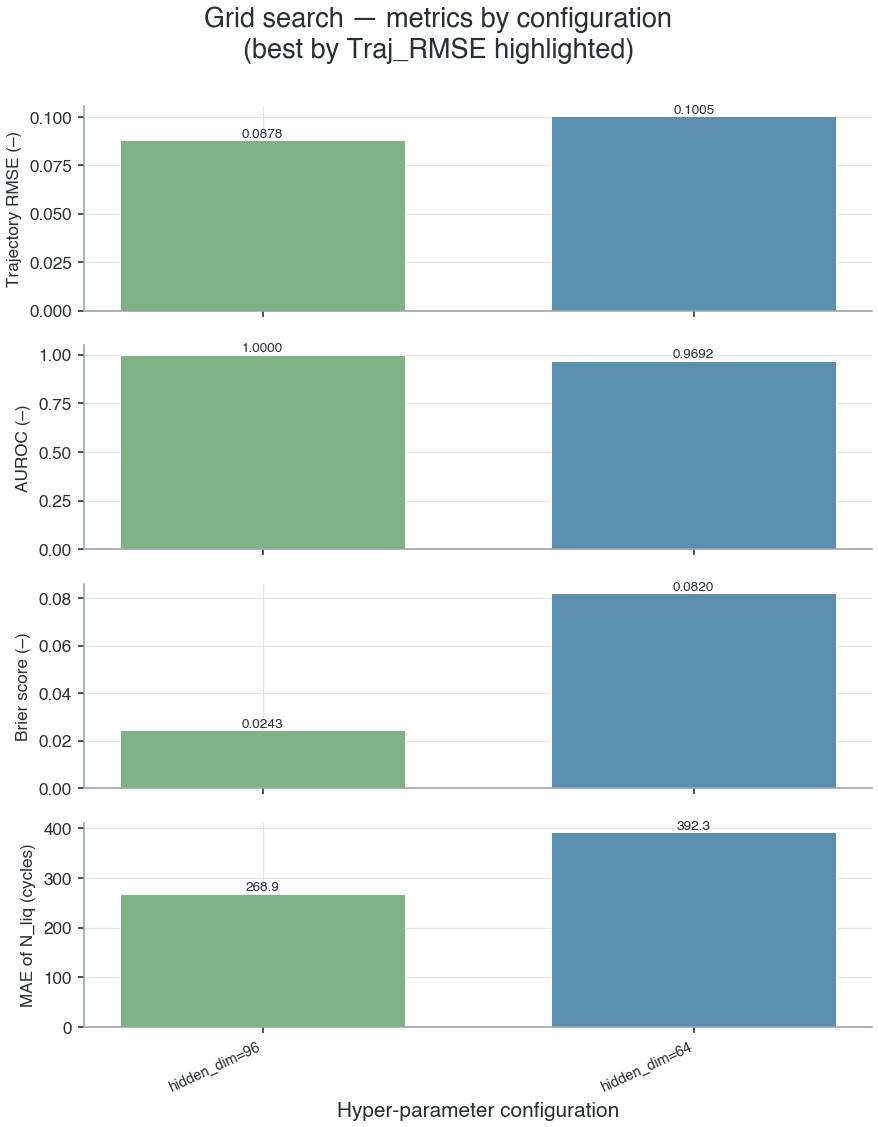

[FT-Transformer] selection metric = Brier | best = {'n_layers': 2}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,2,0.2678,438.7756,792.8991,0.8911,1.2455,101.0,1.1980,507.1216,0.0411,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,3,0.4572,546.6234,957.5617,0.9361,1.4367,101.0,1.2647,668.7179,0.2055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


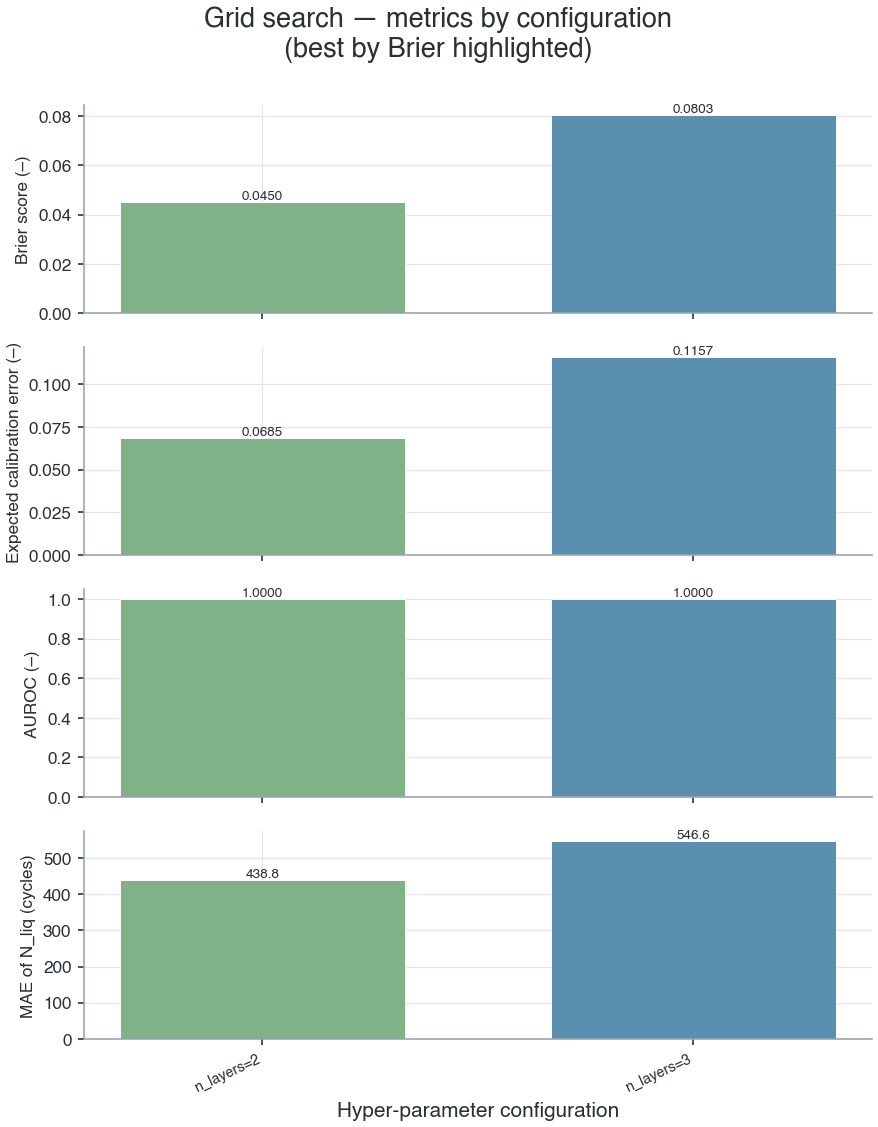

[PINN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,1.1458,1017.4948,1054.4351,1.7259,1.9308,101.0,2.1822,931.4629,0.0,...,0.4368,0.9130,0.5205,0.0476,-0.3868,0.0935,NaN,0.0,0.0,0.0
1,64,0.7186,1281.8940,1346.7175,1.9784,2.2857,101.0,2.6320,1498.0714,0.0,...,0.3949,0.8611,0.4705,0.1322,-0.2868,0.1001,NaN,0.0,0.0,0.0


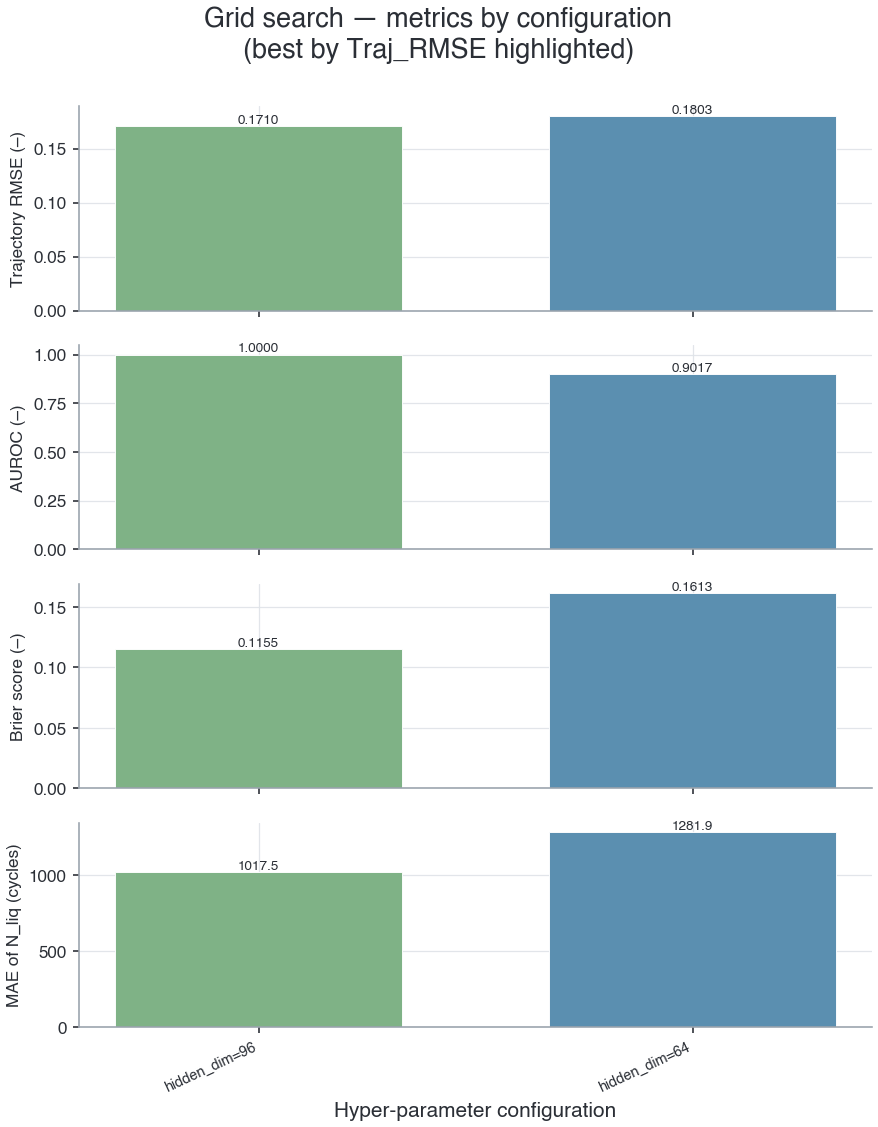

[DeepState] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-1.5727,510.0034,860.7523,0.6989,0.9686,101.0,0.7476,244.1573,0.3288,...,0.2914,0.8541,0.3472,0.0985,-0.7367,0.0696,NaN,0.0,0.0,0.0
1,64,-0.9111,1534.1232,1552.0719,2.1235,2.3954,101.0,2.7487,1674.6718,0.0000,...,0.5676,0.9747,0.6764,0.0474,-0.5408,0.0859,NaN,0.0,0.0,0.0


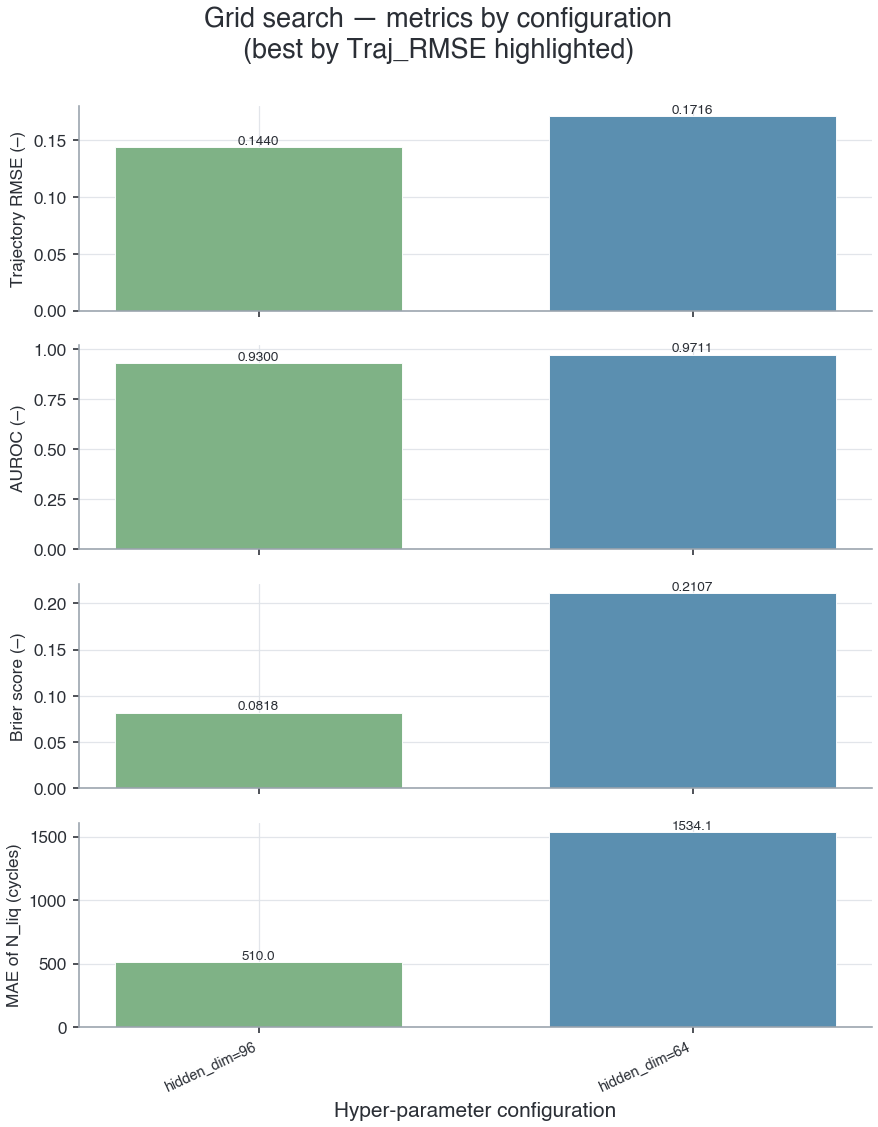

[RealNVP] selection metric = Traj_RMSE | best = {'n_layers': 4}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,4,0.6779,448.5742,611.1343,0.7606,0.9524,101.0,0.9014,254.8940,0.1370,...,0.3031,0.7748,0.3612,0.2186,-0.1099,0.0945,NaN,0.0,0.0,0.0
1,6,0.9356,536.5825,847.8309,0.7254,0.8630,101.0,0.7241,164.2787,0.3425,...,0.4224,0.7292,0.5033,0.2755,0.4505,0.1338,NaN,0.0,0.0,0.0


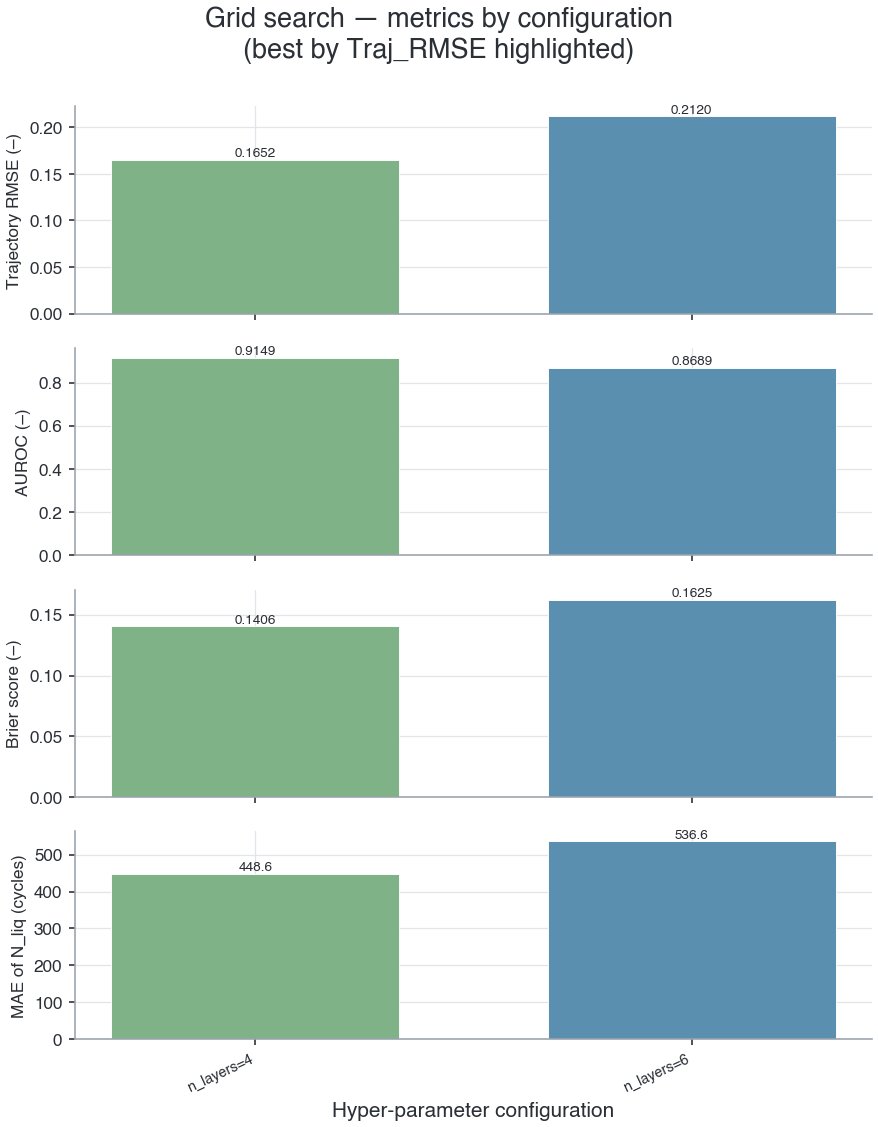

[Neural Spline Flow] selection metric = Traj_RMSE | best = {'n_layers': 4}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,4,7.8676,417.4226,726.9162,0.5534,0.6228,101.0,0.5338,68.7806,0.7397,...,0.4424,0.8730,0.5272,0.1771,-0.1840,0.1084,NaN,0.0,0.0,0.0
1,5,7.6160,474.6270,814.2007,0.5971,0.7135,101.0,0.5533,90.3739,0.5616,...,0.4749,0.8716,0.5659,0.1852,0.0646,0.1255,NaN,0.0,0.0,0.0


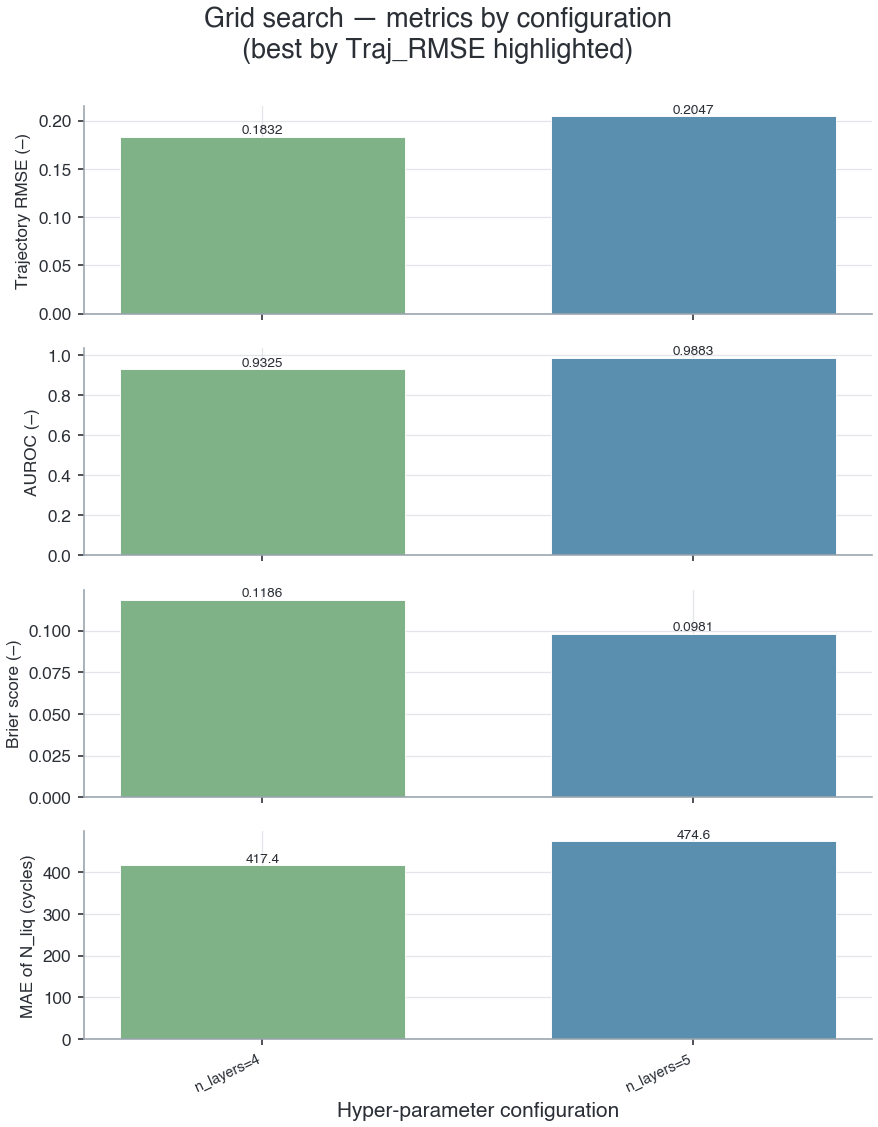

In [3]:
base_specs = {
    "mlp_risk": dict(display="MLP-Risk", cls=RiskMLP,
                     fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                     grid={"hidden_dim": [64, 128]}, score="Brier",
                     metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "gru": dict(display="GRU", cls=GRUBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "tcn": dict(display="TCN", cls=TCNBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "lstm": dict(display="LSTM", cls=LSTMBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "transformer": dict(display="Transformer", cls=TransformerBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim, seq_len=config.seq_len),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "ft_transformer": dict(display="FT-Transformer", cls=FTTransformer,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                 grid={"n_layers": [2, 3]}, score="Brier",
                 metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "pinn": dict(display="PINN", cls=PINNBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "deepstate": dict(display="DeepState", cls=DeepStateBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "realnvp": dict(display="RealNVP", cls=RealNVPFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 6]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "nsf": dict(display="Neural Spline Flow", cls=NeuralSplineFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 5]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
}

for name, spec in base_specs.items():
    cls, fixed, grid, score = spec["cls"], spec["fixed"], spec["grid"], spec["score"]
    res, best = grid_search(lambda p, cls=cls, fixed=fixed: cls(**fixed, **p),
                            grid, gs_train, gs_val, config, device, search_epochs=config.grid_search_epochs, score_metric=score)
    write_hyperparams(MODELS_DIR, name, {"model_type": cls.__name__, "display_name": spec["display"],
                      "model_kwargs": {**fixed, **best}, "search": {"grid": grid, "score_metric": score, "best": best}})
    print(f"[{spec['display']}] selection metric = {score} | best = {best}")
    display(english_metric_table(res).round(4))
    show_grid_dashboard(res, grid, score, spec["metrics"], f"2_1_grid_search_{name}").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
# Реестр классов всех baseline (имя класса -> класс) и число эпох по семействам
CLS = {RiskMLP.__name__: RiskMLP, GRUBaseline.__name__: GRUBaseline, TCNBaseline.__name__: TCNBaseline,
       LSTMBaseline.__name__: LSTMBaseline, TransformerBaseline.__name__: TransformerBaseline,
       FTTransformer.__name__: FTTransformer, PINNBaseline.__name__: PINNBaseline,
       DeepStateBaseline.__name__: DeepStateBaseline, RealNVPFlow.__name__: RealNVPFlow,
       NeuralSplineFlow.__name__: NeuralSplineFlow}
# PINN — физически-структурированная (больше эпох); остальные baseline — config.baseline_epochs
epoch_map = {name: (config.publication_physics_epochs if name == "pinn" else config.publication_baseline_epochs) for name in base_specs}
histories = {}
for name in base_specs:
    hp = read_hyperparams(MODELS_DIR, name)
    model = CLS[hp["model_type"]](**hp["model_kwargs"]).to(device)
    epochs = epoch_map[name]
    model, history = train_model(model, benchmark["train"], benchmark["val"], epochs=epochs,
                                 model_name=hp["display_name"], config=config, device=device, track_metrics=True)
    save_trained_model(model, MODELS_DIR, name, {**hp, "epochs": len(history), "learning_rate": config.learning_rate,
                       "weight_decay": config.weight_decay, "batch_size": config.batch_size, "seed": config.seed}, history)
    histories[hp["display_name"]] = history
    print("saved:", MODELS_DIR / name)

[MLP-Risk] эпоха 01 | обучение=0.7062 | валидация=0.2760 | val_AUROC=1.000 | stale=0/25
[MLP-Risk] эпоха 02 | обучение=0.2881 | валидация=0.2534 | val_AUROC=0.978 | stale=0/25
[MLP-Risk] эпоха 03 | обучение=0.1673 | валидация=0.1401 | val_AUROC=0.986 | stale=0/25
[MLP-Risk] эпоха 04 | обучение=0.1187 | валидация=0.1278 | val_AUROC=0.990 | stale=0/25
[MLP-Risk] эпоха 05 | обучение=0.0976 | валидация=0.1776 | val_AUROC=0.993 | stale=1/25
[MLP-Risk] эпоха 06 | обучение=0.0734 | валидация=0.2396 | val_AUROC=0.986 | stale=2/25
[MLP-Risk] эпоха 07 | обучение=0.0647 | валидация=0.2561 | val_AUROC=0.982 | stale=3/25
[MLP-Risk] эпоха 08 | обучение=0.0663 | валидация=0.2713 | val_AUROC=0.969 | stale=4/25
[MLP-Risk] эпоха 09 | обучение=0.0491 | валидация=0.3199 | val_AUROC=0.960 | stale=5/25
[MLP-Risk] эпоха 10 | обучение=0.0450 | валидация=0.3227 | val_AUROC=0.950 | stale=6/25
[MLP-Risk] эпоха 11 | обучение=0.0406 | валидация=0.3270 | val_AUROC=0.932 | stale=7/25
[MLP-Risk] эпоха 12 | обучение=0

## Кривые обучения с метриками

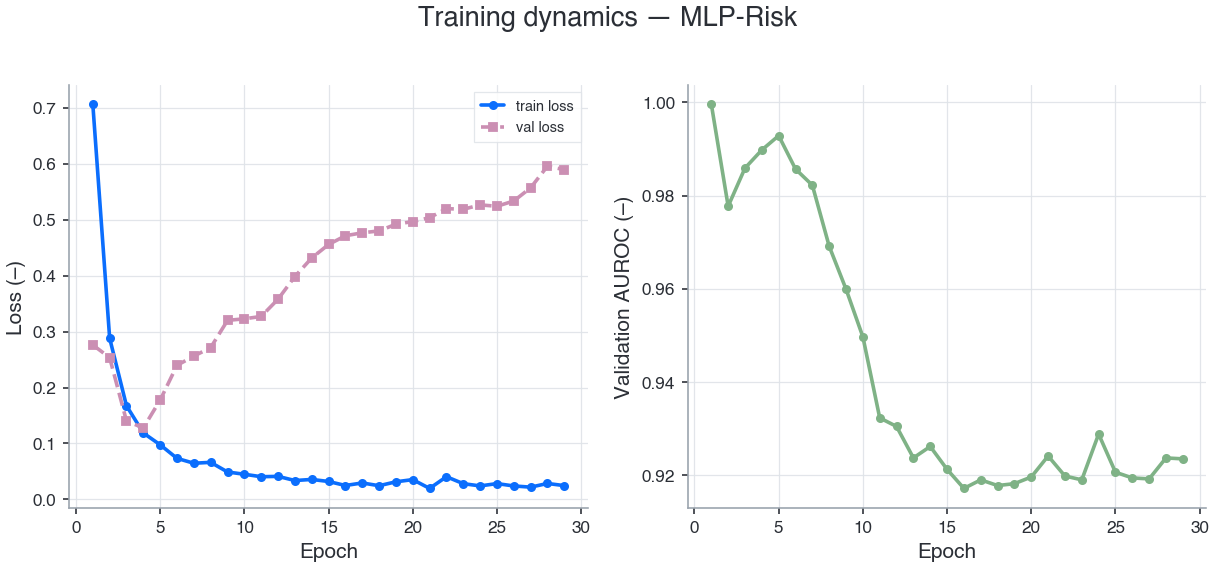

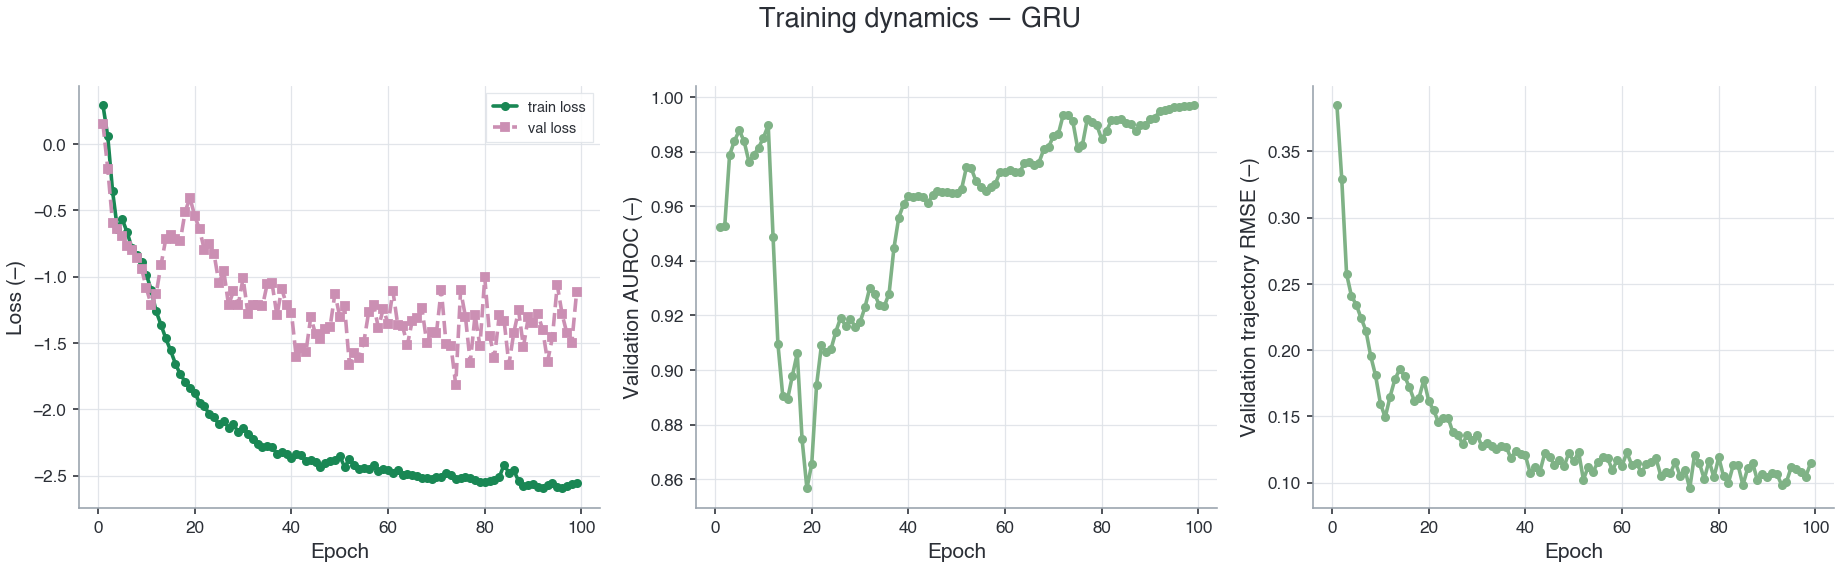

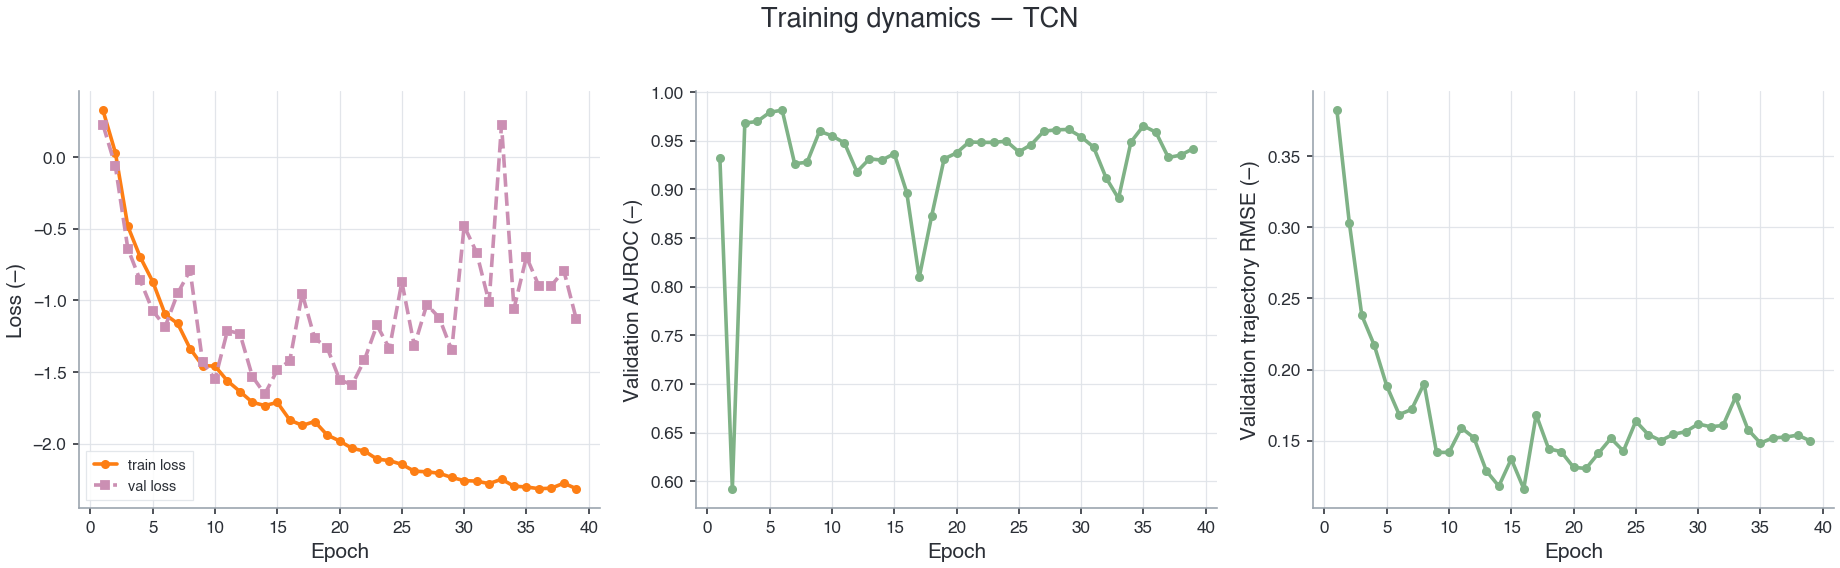

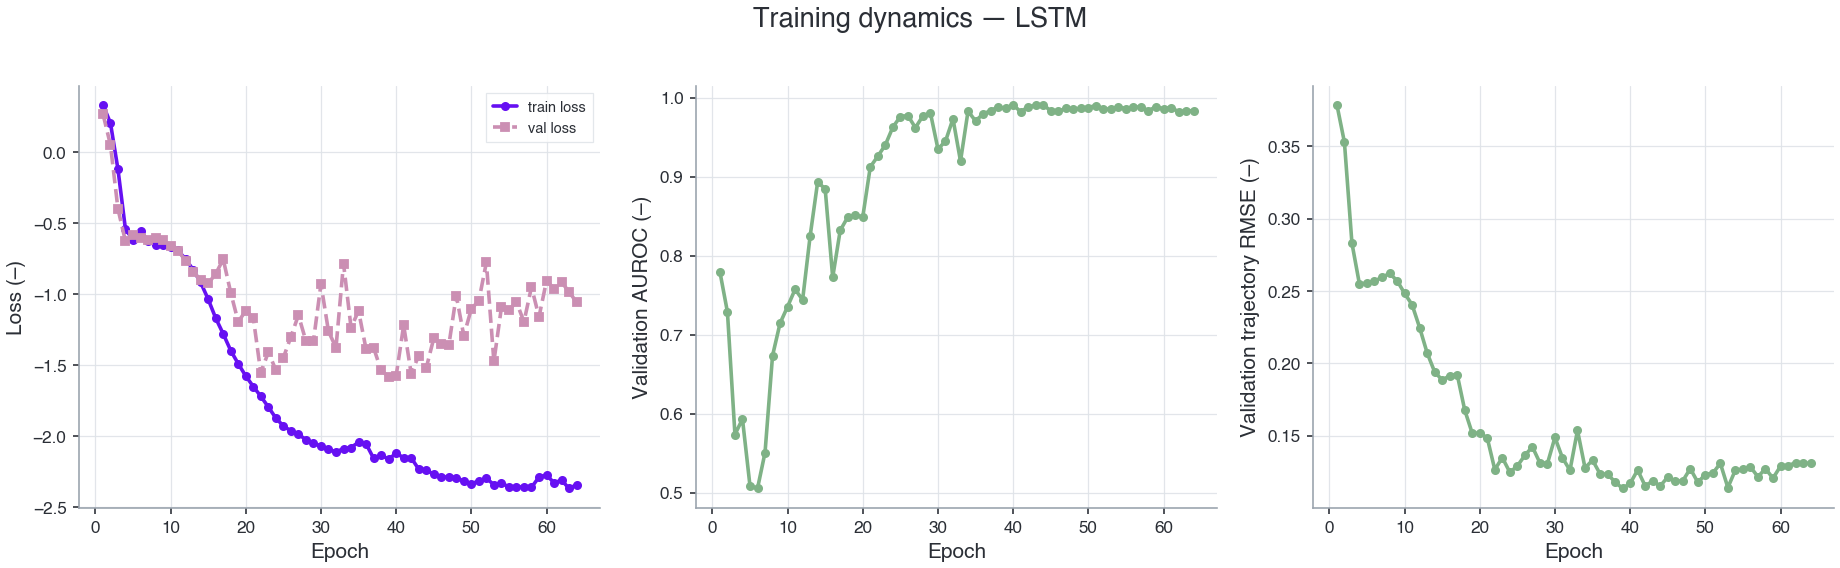

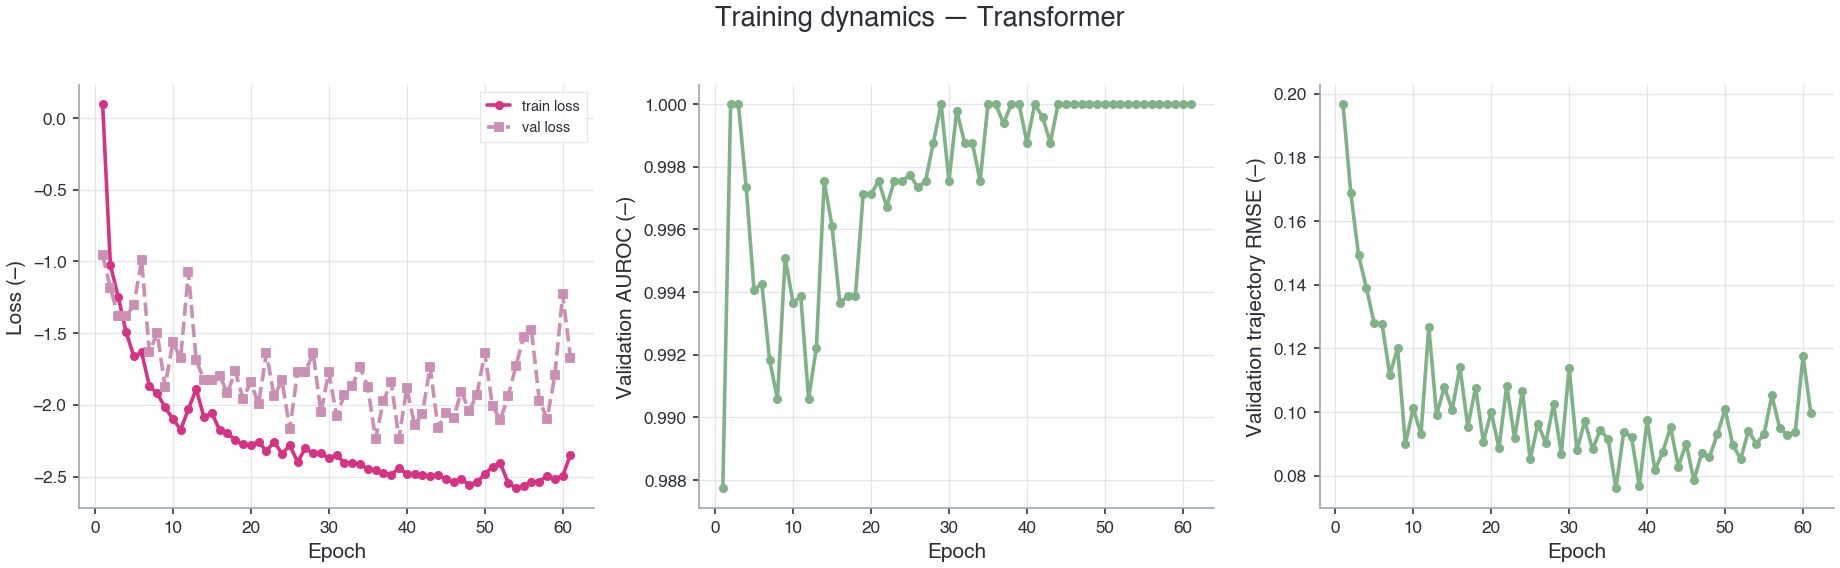

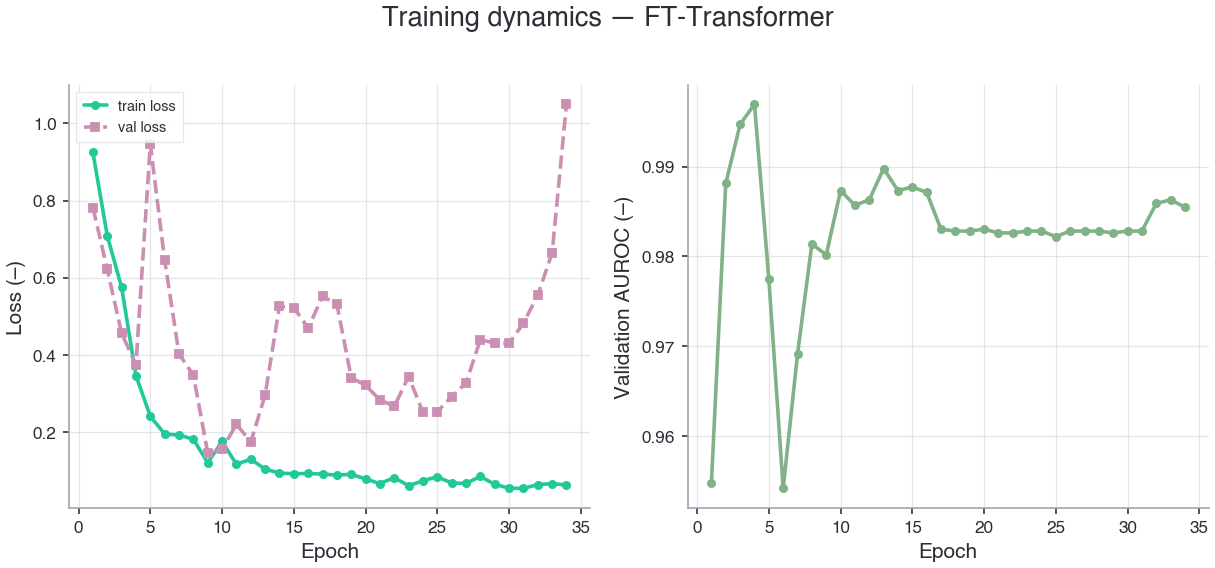

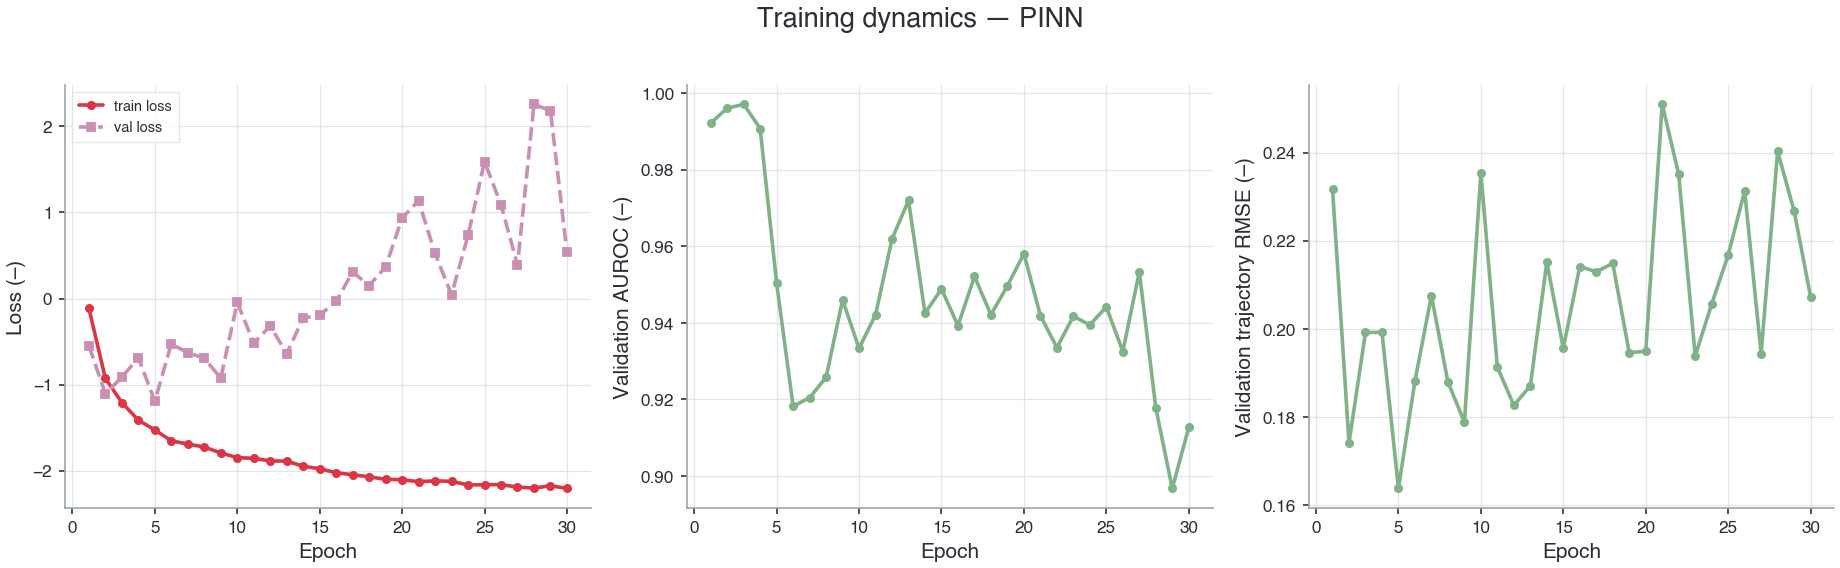

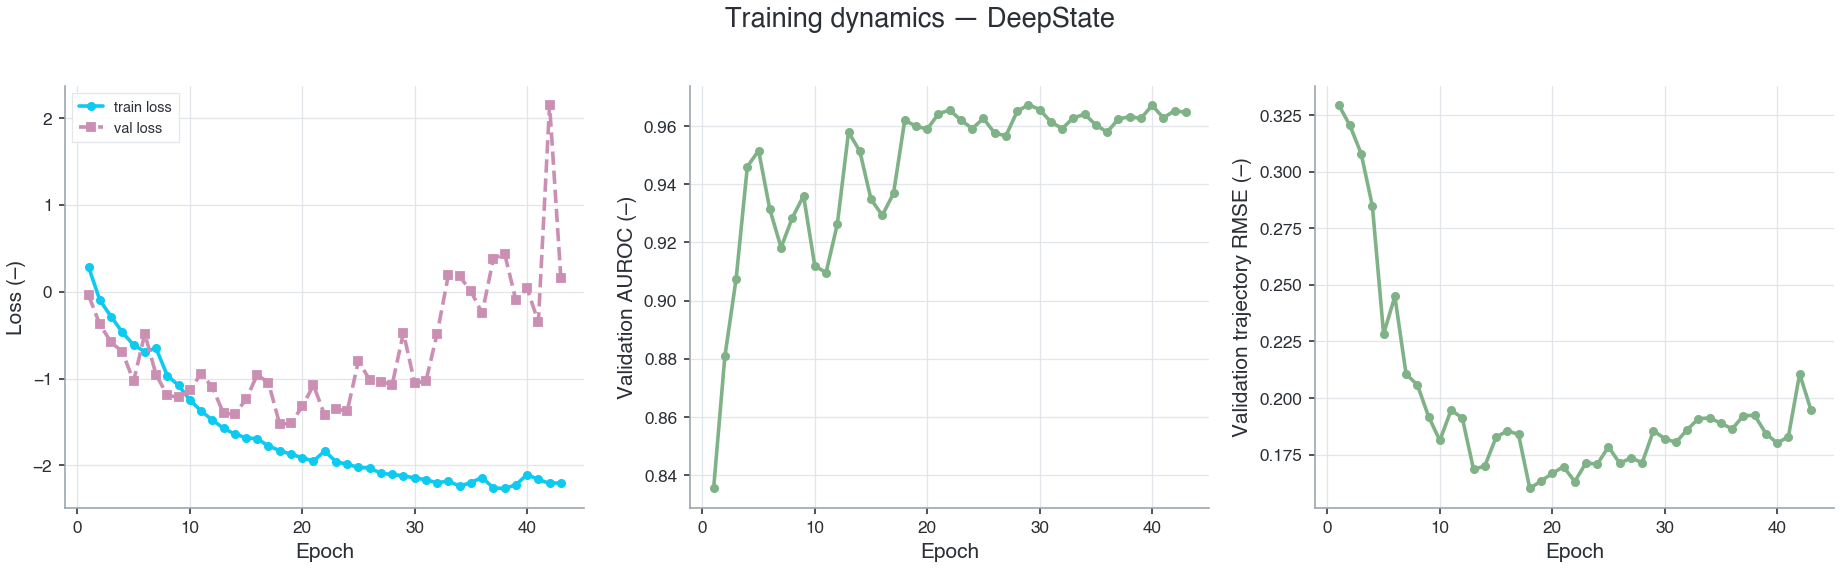

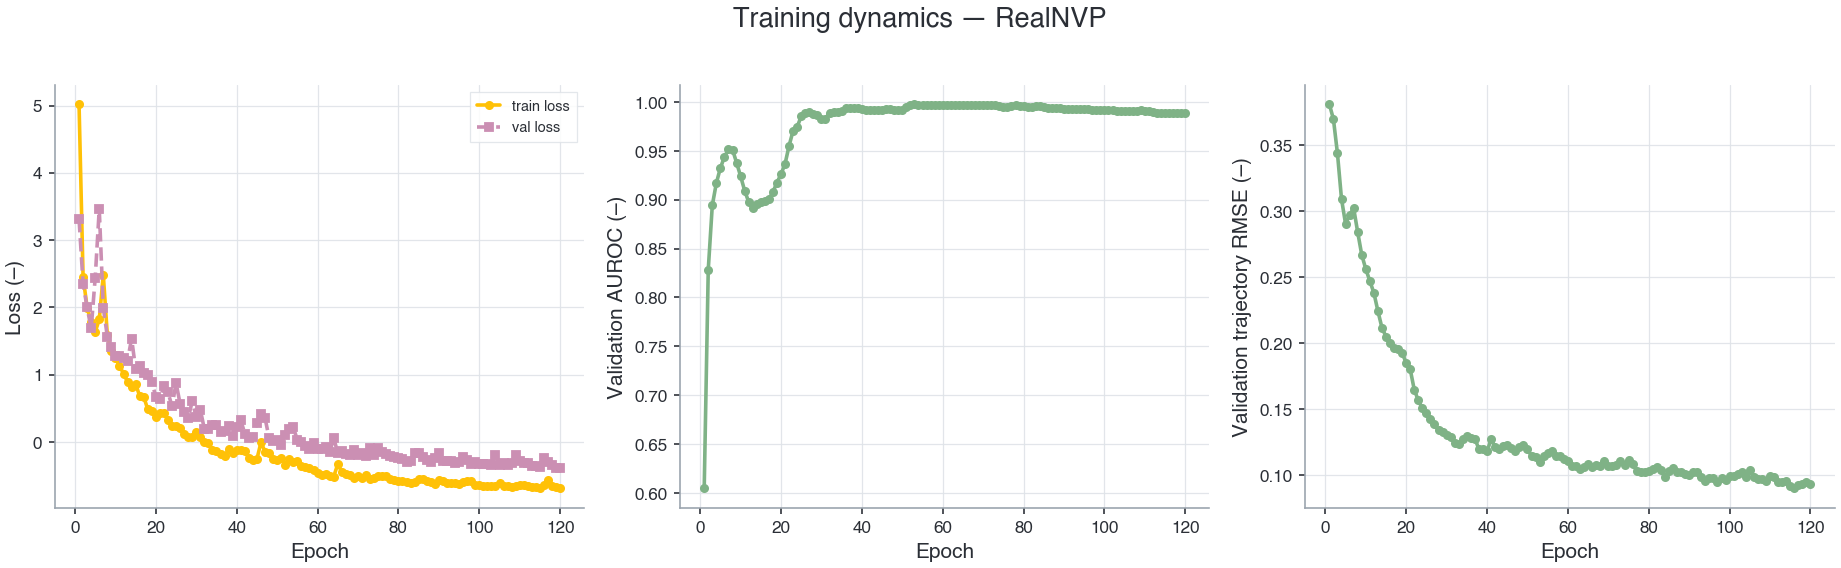

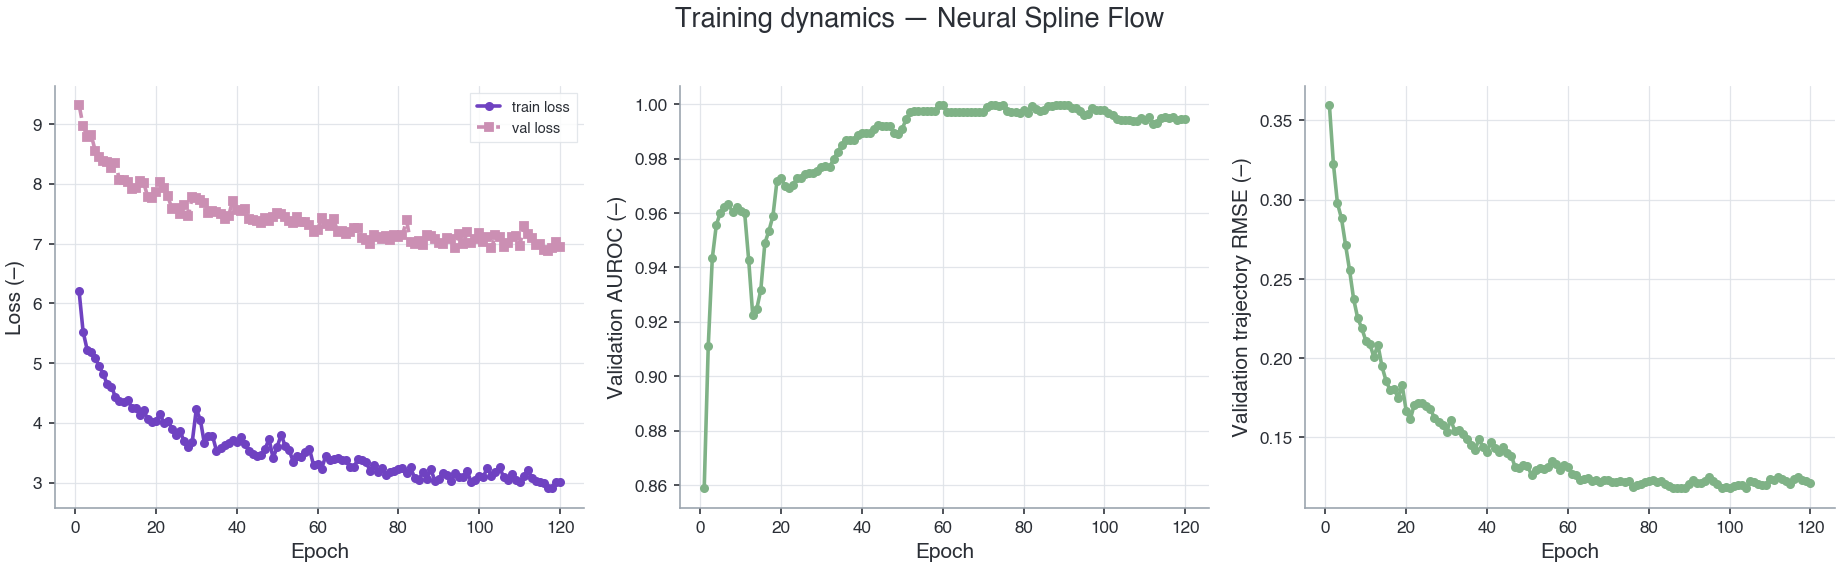

In [5]:
palette = ["#0b6efd", "#198754", "#fd7e14", "#6610f2", "#d63384", "#20c997", "#dc3545", "#0dcaf0", "#ffc107", "#6f42c1"]
colors = {disp: palette[i % len(palette)] for i, disp in enumerate(histories)}
for disp, hist in histories.items():
    training_dashboard(hist, title=f"Training dynamics — {disp}", model_color=colors[disp],
                       save=SAVE_FIGS, fig_id=f"2_1_training_{disp.lower().replace('-', '_')}").show()

## Итог

Базовые модели подобраны grid search (с выбором метрики) и обучены. Дальше — **2.2 DPI-Flow**.

In [6]:
# --- CatBoost (табличный градиентный бустинг) ---
# Не нейросеть, поэтому обучается своим .fit (не train_model) и сохраняется нативно.
cb = CatBoostBaseline(static_dim, prefix_dim).fit(benchmark["train"], benchmark["val"])
cb.save(MODELS_DIR, "catboost")
write_hyperparams(MODELS_DIR, "catboost", {"model_type": "CatBoostBaseline", "display_name": "CatBoost",
                  "model_kwargs": dict(static_dim=static_dim, prefix_dim=prefix_dim)})
print("saved:", MODELS_DIR / "catboost")

saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/catboost
